In [ ]:
import os
# The jupyter notebook is launched from your $HOME directory.
# Change the working directory to your username directory under /scratch/cd82
os.chdir(os.path.expandvars("/scratch/cd82/$USER/"))

# Image Classification with Convolutional Neural Networks

## Episode 05 Evaluate a Convolutional Neural Network and Make Predictions (Classifications)


In [27]:
# # load the required packages
# from tensorflow import keras # data and neural network
# import seaborn as sns # specialised plotting
# import pandas as pd # handles dataframes
# import numpy as np # for argmax
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

## Step 7. Perform a Prediction/Classification

After you fully train the network to a satisfactory performance on the training and validation sets, we use it to perform predictions on a special hold-out set, the test set. The prediction accuracy of the model on new images will be used in Step 8. Measuring performance to measure the performance of the network.

In [21]:
# emg use to inspect environment and determine if test_images are already loaded and normalised
if 'test_images' in locals():
    print('The test dataset is already loaded.')
    print('The images have values between ', str(test_images.min()), ' and', str(test_images.max()))

The test dataset is already loaded.
The images have values between  0  and 255


### Prepare test dataset

In [22]:
# load the CIFAR-10 dataset included with the keras library
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

# create a list of classnames 
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# normalize the RGB values to be between 0 and 1
test_images = test_images / 255.0

# check test image dataset is loaded - images and labels
print('Test: Images=%s, Labels=%s' % (test_images.shape, test_labels.shape))

Test: Images=(10000, 32, 32, 3), Labels=(10000, 1)


## CHALLENGE Write the code to make class predictions on test data

Use the Model.predict() function to predict the classnames of your test data.

Hint 1: If not already in memory, use ‘keras.models.load_model()’

Hint 2: Capture the output of the predict method in a variable named ‘predictions’.

Question: What did the predict method return?

In [ ]:
# # load preferred model
# _____ = keras.models.load_model(_____)

# # use preferred model to predict
# _____ = _____.predict(x=_____)

In [ ]:
## SOLUTION


## SOLUTION

In [23]:
# load preferred model
model_best = keras.models.load_model('model_dropout.keras')
print('We are using', model_best.name)

# use preferred model to predict probability of each class on new test set
predictions = model_best.predict(x=test_images)

print(predictions)

We are using cifar_model_dropout
313/313 [==============================] - 1s 2ms/step
[[1.96753405e-02 2.16306094e-03 5.87523505e-02 ... 6.01762952e-03
  6.27985820e-02 6.86700270e-03]
 [2.20877328e-03 1.23180486e-01 1.34735501e-06 ... 9.55401447e-09
  8.73770893e-01 8.37149331e-04]
 [1.87059402e-01 5.10683358e-02 1.26774646e-02 ... 6.78411499e-03
  6.79451704e-01 3.97192053e-02]
 ...
 [5.20454720e-04 3.88940725e-06 1.65546257e-02 ... 7.89428223e-03
  1.69874635e-04 1.12052367e-05]
 [9.82981101e-02 5.05165160e-01 2.44933721e-02 ... 1.78023428e-02
  2.88349041e-03 9.28615499e-03]
 [3.22366964e-06 2.44297530e-06 2.87000119e-04 ... 8.89044166e-01
  1.77943988e-07 2.26197881e-06]]


In [25]:
# convert probability predictions to table using class names for column names
import numpy as np
prediction_df = pd.DataFrame(data=predictions, columns=class_names)

# inspect 
print(prediction_df.head())

# convert predictions to class labels
predicted_labels = np.argmax(a=predictions, axis=1)
print(predicted_labels)

   airplane  automobile      bird       cat          deer           dog  \
0  0.019675    0.002163  0.058752  0.583296  4.239913e-03  2.216571e-01   
1  0.002209    0.123180  0.000001  0.000001  3.987405e-08  1.049581e-08   
2  0.187059    0.051068  0.012677  0.014397  2.923428e-03  2.107289e-03   
3  0.603080    0.082061  0.023244  0.002822  1.022614e-03  4.119949e-04   
4  0.000247    0.000060  0.024994  0.036516  3.141422e-01  6.270218e-03   

           frog         horse      ship     truck  
0  3.453262e-02  6.017630e-03  0.062799  0.006867  
1  6.219883e-08  9.554014e-09  0.873771  0.000837  
2  3.811837e-03  6.784115e-03  0.679452  0.039719  
3  8.682476e-04  2.072863e-04  0.212872  0.073411  
4  6.174185e-01  1.577102e-04  0.000111  0.000083  
[3 8 8 ... 5 1 7]


## Step 8. Measuring performance

In [28]:
# evaluate the model on the test data set
test_acc = accuracy_score(y_true=test_labels, y_pred=predicted_labels)
print('Accuracy:', round(test_acc, 2))

Accuracy: 0.69


In [29]:
# create a confusion matrix
conf_matrix = confusion_matrix(y_true=test_labels, y_pred=predicted_labels)
print(conf_matrix)

[[741  40  53  13  16   6  15  11  53  52]
 [ 20 841   5  13   7   8  13   1  23  69]
 [ 68   7 563  46  78 103  85  26   8  16]
 [ 17  10  73 463  57 230  96  23   7  24]
 [ 22   8  89  58 612  52  69  73  12   5]
 [  9   3  76 151  52 627  41  28   4   9]
 [  5  11  54  55  30  20 816   3   3   3]
 [ 23   3  37  43  59 116  11 676   1  31]
 [ 91  39  16  21   3  11   8   8 760  43]
 [ 30 121   8  16   4   9   9  14  26 763]]


<Axes: xlabel='Predicted Label', ylabel='True Label'>

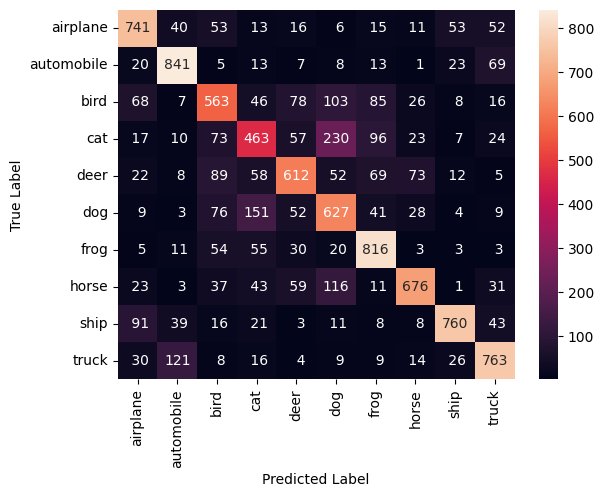

In [30]:
# convert confustion matrix to a pandas dataframe
confusion_df = pd.DataFrame(data=conf_matrix, index=class_names, columns=class_names)

# set the names of the x and y axis, this helps with the readability of the heatmap
confusion_df.index.name = 'True Label'
confusion_df.columns.name = 'Predicted Label'

# heatmap visualization of the confusion matrix
sns.heatmap(data=confusion_df, annot=True, fmt='3g')

## CHALLENGE Confusion Matrix

Measure the performance of the neural network you trained and visualized as a confusion matrix.

Q1. Did the neural network perform well on the test set?

Q2. Did you expect this from the training loss plot?

Q3. What could we do to improve the performance?

In [ ]:
## SOLUTION


In [31]:
!cp -n /scratch/cd82/icwcnn-files/*.ipynb /scratch/cd82/$USER/notebooks/